# ***NOON PERFUME DATASET ANALYSIS:***
---
## ***E-COMMERCE PRODUCT ANALYSIS AND PRICE PREDICTION:***
---
### **Data from Kaggle. File saved as noon_perfumes_dataset.csv**



## **1.Import Libraries:**


In [2]:
#Import python libraries
import pandas as pd  #import pandas and give a short name or alias "pd" for working with data like tables, CSV files, etc.
import numpy as np   # import numpy & give alias as "np" for numerical operations like arrays, mathematical functions
import matplotlib.pyplot as plt #import pyplot module from matplotlib and give alias "plt" for creating graphs and visualizations
import seaborn as sns #Import seaborn and give alias"sns" for advanced and attractive data visualization

In [51]:
# Import LabelEncoder and StandardScaler from preprocessing module
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV

## **2. Load Dataset:**

In [4]:
perfume = pd.read_csv('noon_perfumes_dataset.csv')
perfume.head()

,Unnamed: 0,brand,name,old_price,new_price,ml,concentration,department,scents,base_note,middle_note,item_rating,seller,seller_rating,num_seller_ratings
0,0,PACO RABANNE,1 Million Lucky,395.0,244.55,100,EDT,Men,Woody,"Oakmoss, Patchouli and Vetiver","Hazelnut, Jasmine, Cashmir Wood, Cedar and Honey",5.0,noon,4.2,98.1K
1,1,Roberto Cavalli,Paradiso Assoluto,415.0,107.95,50,EDP,Women,Floral,"Vanilla, Sandalwood And Patchouli",Wild Jasmine and Red Lily,4.8,noon,4.2,98.1K
2,2,S.T.Dupont,Royal Amber,265.0,186.90,100,EDP,Unisex,Arabian,"Lemon, Mint and Wood Moss",Sandalwood and Cedar,5.0,noon,4.2,98.1K
3,3,GUESS,Seductive Blue,290.0,103.20,100,EDT,Men,Spicy,"Cashmere Wood, Moss And Rippled Sand Accord",Blue Coral Aquaspace Accord And Geranium,3.0,noon,4.2,98.1K
4,4,Roberto Cavalli,Uomo,260.0,94.95,50,EDP,Women,Arabian,"Vanille, Benzoin, Tonka Bean",African Orange Flower,4.8,noon,4.2,98.1K


## **3. Data Understanding:**

In [5]:
perfume.shape           #checking number of rows and columns

(1003, 15)

* ### **Cheacking Null Values:**




In [6]:
perfume.isnull().sum()

,0
Unnamed: 0,0
brand,0
name,0
old_price,0
new_price,0
ml,0
concentration,0
department,0
scents,0
base_note,0


In [7]:
#since we have no null values so we can't perform dropna() and fillna() and
#mean,mode imputation was not required.but we know that mean is used for
#numerical features and mode for categorical features when missing data exists
# Numeric columns → mean
for col in perfume.select_dtypes(include=np.number).columns:
    perfume[col] = perfume[col].fillna(perfume[col].mean())

# Categorical columns → mode
for col in perfume.select_dtypes(include='object').columns:
    perfume[col] = perfume[col].fillna(perfume[col].mode()[0])
# since there is no null values data cannot be changed its just for example

In [8]:
print("\nColumns:", perfume.columns)
print(perfume.info())
print(perfume.describe())


Columns: Index(['Unnamed: 0', 'brand', 'name', 'old_price', 'new_price', 'ml',
       'concentration', 'department', 'scents', 'base_note', 'middle_note',
       'item_rating', 'seller', 'seller_rating', 'num_seller_ratings'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1003 entries, 0 to 1002
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          1003 non-null   int64  
 1   brand               1003 non-null   object 
 2   name                1003 non-null   object 
 3   old_price           1003 non-null   float64
 4   new_price           1003 non-null   float64
 5   ml                  1003 non-null   int64  
 6   concentration       1003 non-null   object 
 7   department          1003 non-null   object 
 8   scents              1003 non-null   object 
 9   base_note           1003 non-null   object 
 10  middle_note         1003 non-null   object 
 11  i

* ### **Drop Useless Columns:**
---
droping columns which has the number of different entries or unique values


In [9]:
print(perfume.nunique())

Unnamed: 0            1003
brand                  160
name                   594
old_price              438
new_price              644
ml                      28
concentration            5
department               4
scents                  22
base_note              739
middle_note            726
item_rating             23
seller                 117
seller_rating           15
num_seller_ratings      60
dtype: int64


### **Top 10 Brands plot**

In [10]:
perUp=perfume.drop(columns=['Unnamed: 0','name','base_note','middle_note','seller'])

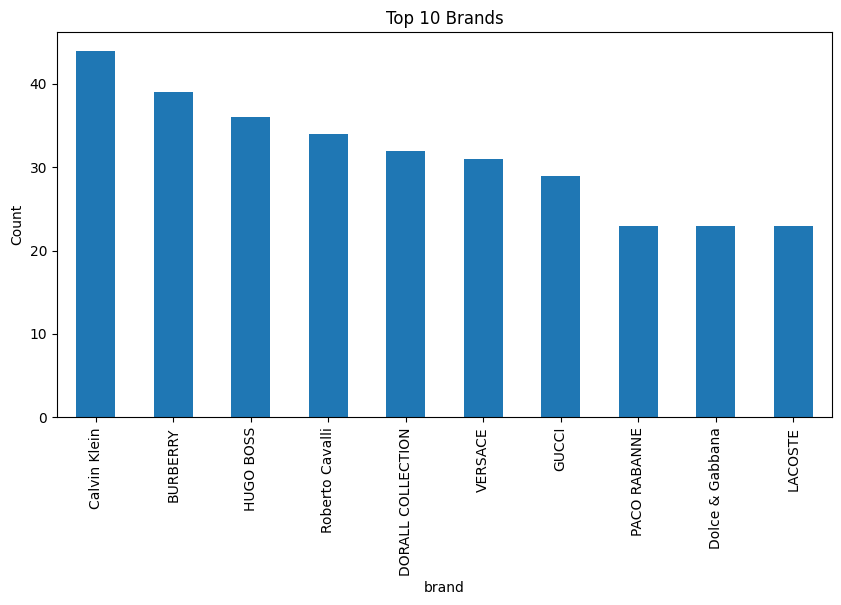

In [44]:
plt.figure(figsize=(10,5))
perUp['brand'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Brands")
plt.ylabel("Count")
plt.show()


### **Countplot of Department**

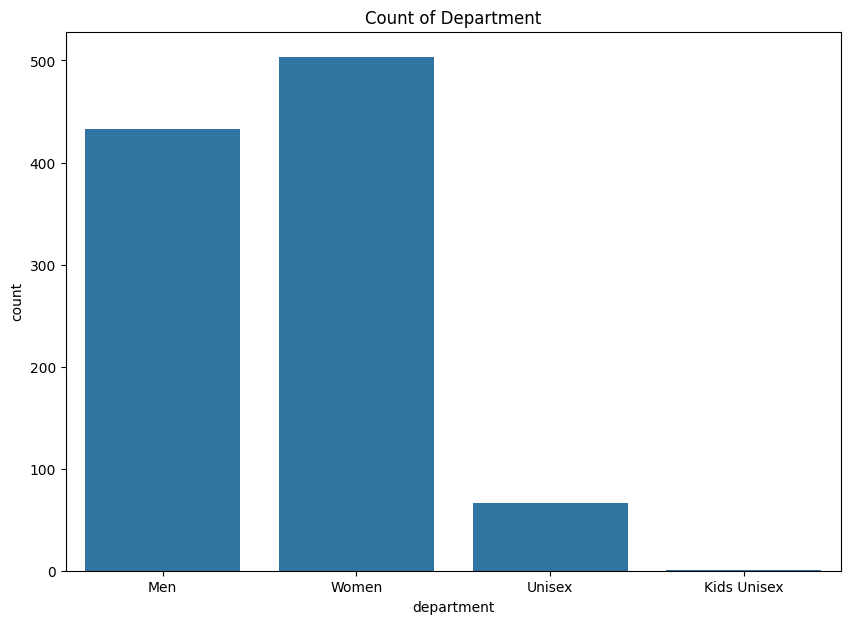

In [41]:
plt.figure(figsize=(10,7))
sns.countplot(x='department', data=perUp)
plt.title("Count of Department")
plt.show()

In [11]:
perUp

,brand,old_price,new_price,ml,concentration,department,scents,item_rating,seller_rating,num_seller_ratings
0,PACO RABANNE,395.0,244.55,100,EDT,Men,Woody,5.0,4.2,98.1K
1,Roberto Cavalli,415.0,107.95,50,EDP,Women,Floral,4.8,4.2,98.1K
2,S.T.Dupont,265.0,186.90,100,EDP,Unisex,Arabian,5.0,4.2,98.1K
3,GUESS,290.0,103.20,100,EDT,Men,Spicy,3.0,4.2,98.1K
4,Roberto Cavalli,260.0,94.95,50,EDP,Women,Arabian,4.8,4.2,98.1K
...,...,...,...,...,...,...,...,...,...,...
998,GUESS,170.0,75.00,100,EDT,Women,Citrus,4.9,4.2,98.1K
999,BURBERRY,378.0,153.75,100,EDT,Women,Fruity,4.8,4.2,98.1K
1000,JOVAN,55.0,19.00,59,EDT,Women,Woody,4.7,3.7,1.9K
1001,SWISS ARABIAN,126.0,77.00,15,EDT,Unisex,Arabian,4.0,3.9,5


In [12]:
perUp.shape

(1003, 10)

## **4. Outlier Detection & Removal:**

* ### **Detect Outliers with Boxplot**

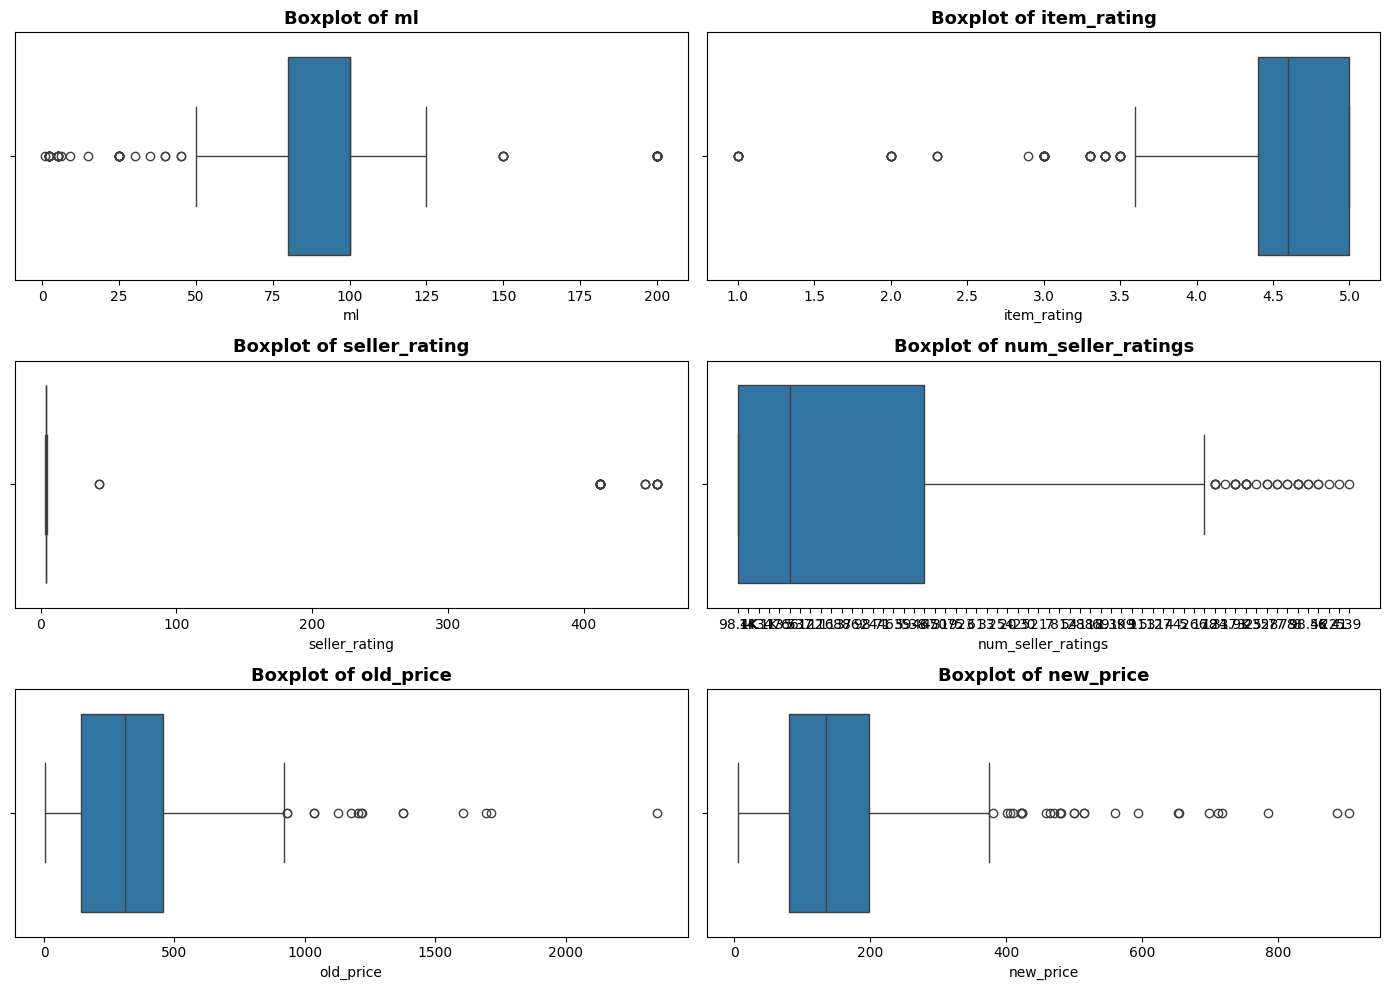

In [46]:
cols_check =['ml','item_rating','seller_rating','num_seller_ratings','old_price','new_price']
plt.figure(figsize=(14,10))
for i, col in enumerate(cols_check, 1):
  plt.subplot(3, 2, i)
  sns.boxplot(x=perUp[col])
  plt.title(f'Boxplot of {col}', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

* ### **Remove Outliers**

In [14]:
# removing outliers from selected numeric cols using IQR method
cols_remove = ['ml','old_price','new_price']

#copying dataset
perClean = perUp.copy()

for col in cols_remove:
  Q1 = perClean[col].quantile(0.25)
  Q3 = perClean[col].quantile(0.75)
  IQR = Q3-Q1

  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  perClean = perClean[
      (perClean[col]>= lower) & (perClean[col]<= upper)
  ]
print("Original Shape: ", perUp.shape)
print("After Outliers Removal: ",perClean.shape)

Original Shape:  (1003, 10)
After Outliers Removal:  (908, 10)


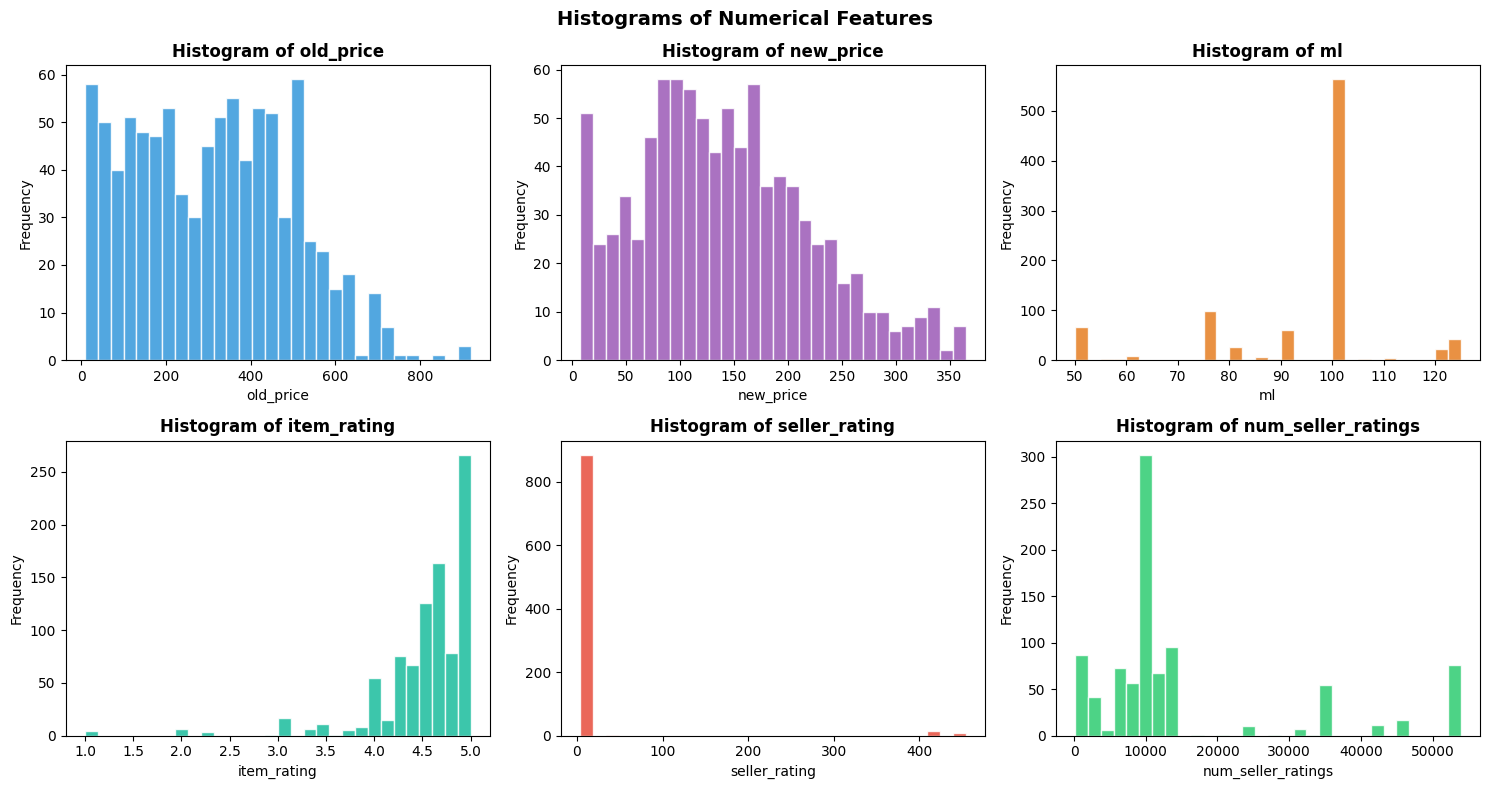

In [47]:
# Histogram Of Numeric Cols
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

num_cols = ['old_price', 'new_price', 'ml', 'item_rating', 'seller_rating', 'num_seller_ratings']
colors = ['#3498db','#9b59b6','#e67e22','#1abc9c','#e74c3c','#2ecc71']

for i, col in enumerate(num_cols):
    axes[i].hist(perClean[col], bins=30, color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Histogram of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Histograms of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **6. Feature Engineering:**

In [19]:
# adding a new column to check the discount
perClean['discount_percent']=((perClean['old_price']-perClean['new_price']) / perClean['old_price']) * 100
perClean.head()

,brand,old_price,new_price,ml,concentration,department,scents,item_rating,seller_rating,num_seller_ratings,discount_percent,price_per_ml
0,PACO RABANNE,395.0,244.55,100,EDT,Men,Woody,5.0,4.2,98.1K,38.088608,2.4455
1,Roberto Cavalli,415.0,107.95,50,EDP,Women,Floral,4.8,4.2,98.1K,73.987952,2.1590
2,S.T.Dupont,265.0,186.90,100,EDP,Unisex,Arabian,5.0,4.2,98.1K,29.471698,1.8690
3,GUESS,290.0,103.20,100,EDT,Men,Spicy,3.0,4.2,98.1K,64.413793,1.0320
4,Roberto Cavalli,260.0,94.95,50,EDP,Women,Arabian,4.8,4.2,98.1K,63.480769,1.8990


In [17]:
perClean['price_per_ml'] = perClean['new_price']/perClean['ml']

In [18]:
perClean.shape

(908, 12)

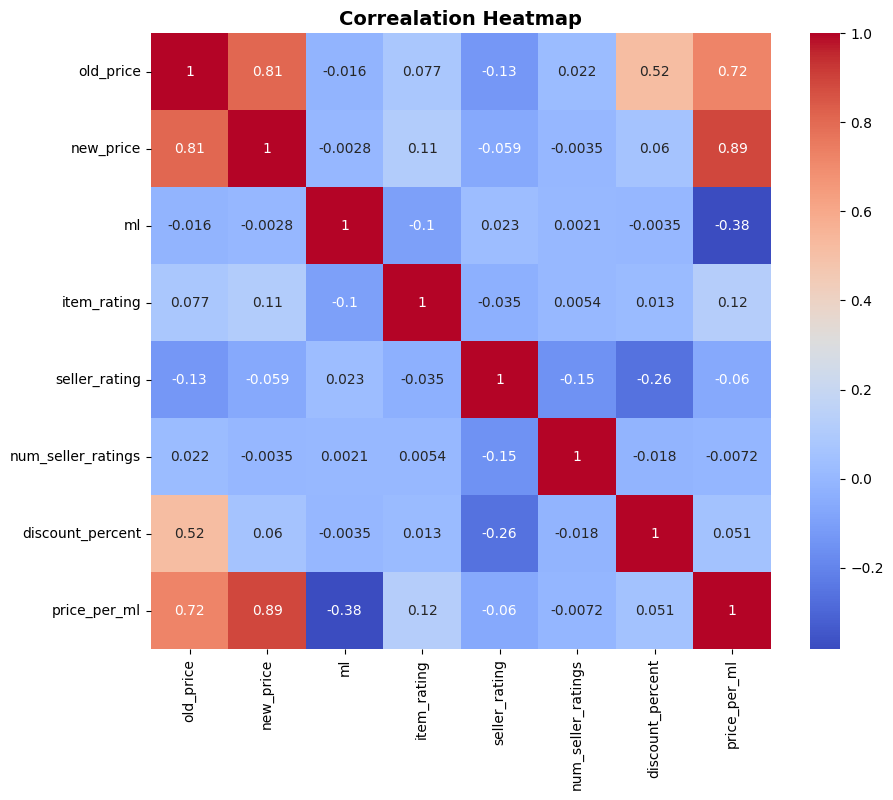

In [45]:
plt.figure(figsize=(10,8))
sns.heatmap(perClean.select_dtypes(include='number').corr(),annot=True, cmap='coolwarm')
plt.title("Correalation Heatmap", fontsize=14, fontweight='bold')
plt.show()

In [23]:
# fix num_seller_ratings values into num

perClean['num_seller_ratings'] = (perClean['num_seller_ratings'].astype(str).str.replace('K', '', regex = False).astype(float) *100)
#checking result
perClean[['num_seller_ratings']].head()

,num_seller_ratings
0,9810.0
1,9810.0
2,9810.0
3,9810.0
4,9810.0


## **7. Encoding Categorical Variables**

In [25]:
model_data = perClean.copy()
cat_cols =['brand','concentration','department','scents']

# apply label encoding
le = LabelEncoder()

for col in cat_cols:
  model_data[col] = le.fit_transform(model_data[col])
model_data.head()

,brand,old_price,new_price,ml,concentration,department,scents,item_rating,seller_rating,num_seller_ratings,discount_percent,price_per_ml
0,105,395.0,244.55,100,2,1,17,5.0,4.2,9810.0,38.088608,2.4455
1,120,415.0,107.95,50,1,3,5,4.8,4.2,9810.0,73.987952,2.1590
2,121,265.0,186.90,100,1,2,0,5.0,4.2,9810.0,29.471698,1.8690
3,52,290.0,103.20,100,2,1,14,3.0,4.2,9810.0,64.413793,1.0320
4,120,260.0,94.95,50,1,3,0,4.8,4.2,9810.0,63.480769,1.8990


### **Define Variable X & y**

In [26]:
X = model_data.drop('new_price', axis=1)
y = model_data['new_price']

### **Train Test Split**

In [28]:
# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape}")
print(f"Test set size:     {X_test.shape}")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())

Training set size: (726, 11)
Test set size:     (182, 11)

Class distribution in training set:
new_price
140.00    7
95.00     6
126.00    5
75.00     5
115.00    5
         ..
326.40    1
187.90    1
202.25    1
138.85    1
262.90    1
Name: count, Length: 499, dtype: int64


## **Model Building:**

In [30]:
# ── Model 1: Linear Regression ──

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Linear Regression R2 Score: ", r2_score(y_test,y_pred_lr))
print("MAE: ", mean_absolute_error(y_test,y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test,y_pred_lr)))

Linear Regression R2 Score:  0.9395227044303759
MAE:  12.85055659914971
RMSE: 19.12669099818237


In [32]:
# ── Model 2: Decision Tree ──
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree R2 Score: ", r2_score(y_test,y_pred_dt))
print("MAE: ", mean_absolute_error(y_test,y_pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test,y_pred_dt)))

Decision Tree R2 Score:  0.9839508001738775
MAE:  3.605494505494505
RMSE: 9.853042426324219


In [33]:
# ── Model 3: Random Forest Regressor ──

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest R2 Score: ", r2_score(y_test,y_pred_rf))
print("MAE: ", mean_absolute_error(y_test,y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test,y_pred_rf)))

Random Forest R2 Score:  0.990383282895021
MAE:  3.5393681318681436
RMSE: 7.6270585605274075


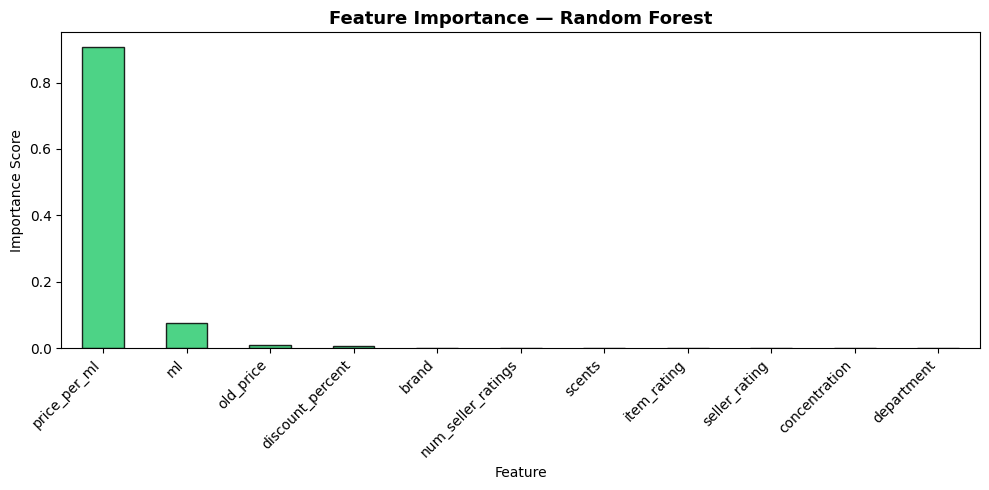

Top 5 most important features:
price_per_ml        0.905885
ml                  0.074546
old_price           0.008190
discount_percent    0.007444
brand               0.001104
dtype: float64


In [50]:
feature_cols= X.columns
feat_importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feat_importance.plot(kind='bar', color='#2ecc71', edgecolor='black', alpha=0.85)
plt.title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
plt.ylabel('Importance Score')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
print(feat_importance.head())

In [34]:
# ── Comparing Results ──

results = {
    'Linear Regression': r2_score(y_test,y_pred_lr),
    'Decision Tree': r2_score(y_test,y_pred_dt),
    'Random Forest': r2_score(y_test,y_pred_rf)
}
print(results)

{'Linear Regression': 0.9395227044303759, 'Decision Tree': 0.9839508001738775, 'Random Forest': 0.990383282895021}


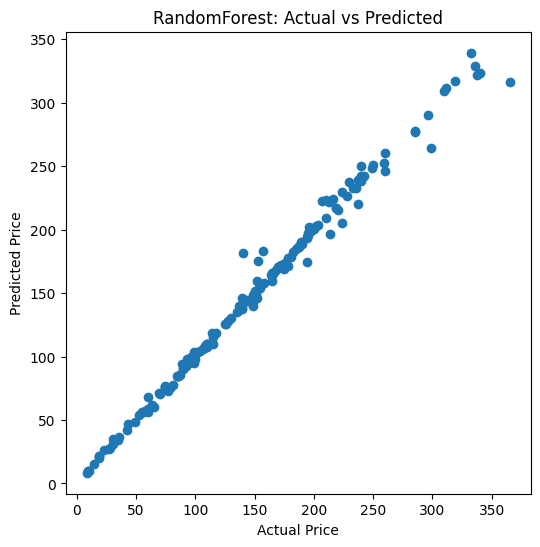

In [36]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("RandomForest: Actual vs Predicted")
plt.show()

In [52]:
param_grid ={
    'n_estimators': [50,100,200],
    'max_depth': [50,10,None]

}
grid = GridSearchCV(
    RandomForestRegressor(random_state=42),param_grid,cv=5,scoring='r2')
grid.fit(X_train, y_train)
print("Best Parameters: ", grid.best_params_)
print("Best Score: ", grid.best_score_)

Best Parameters:  {'max_depth': 10, 'n_estimators': 50}
Best Score:  0.986050063603104


## **Model Evaluation Summary:**
### **Conclusion:**
This project applied machine learning techniques to predict perfume new prices using the perfume dataset.
### **Data Preprocessing::**
* Missing values were checked and handled appropriately.
* Unnecessary columns such as name, seller, and notes were removed.
* Outliers were removed from numerical columns using the IQR method.
* Categorical variables were converted into numerical values using Label Encoding.
* Numerical features were standardized using feature scaling.
### **Feature Engineering:**


*   A new feature discount_percent was created using old_price and new_price.
*  A new feature price_per_ml was created using new_price divided by ml.
* These engineered features helped improve model learning and prediction accuracy.

### **Model Performance:**
* Linear Regression: Performed as a baseline regression model.
* Decision Tree Regressor: Captured complex price patterns but showed slight    overfitting.
* Random Forest Regressor: Best performer with highest R² score and lowest prediction errors.
### **Key Insights from EDA:**
* old_price showed the strongest positive relationship with new_price.
* Larger perfume bottle sizes (ml) generally had higher prices.
* Higher discount percentages were linked with lower selling prices.
* Some premium brands consistently had higher product prices.
* Ratings had minor influence compared to price-related features.

### **Limitations::**
* Dataset size is limited and may not represent the full perfume market.
* External factors such as demand, trends, and promotions were not included.
* Brand popularity and fragrance quality are difficult to measure numerically.
### **Possible Improvements:**
* Apply GridSearchCV for better hyperparameter tuning.
* Use advanced models such as XGBoost or Gradient Boosting.
* Add more features like review count, popularity, stock availability.
* Build a Streamlit web app for real-time perfume price prediction.
### **Final Result:**
The project successfully predicted perfume new_price using machine learning models. Among all tested models, Random Forest Regressor achieved the best overall performance and is recommended as the final model for accurate perfume price prediction



